In [ ]:
# 1. Install required packages quietly
!pip install pytorch-msssim gdown -q

import os

# 2. Download the Pre-trained Model automatically (No popup!)
MODEL_FILE_ID = '12D37JdYxnHpCejwyCVI2354RP8xPZgvJ'
!gdown {MODEL_FILE_ID} -O /content/exxa_autoencoder_weights.pth

# 3. Download and Unzip the Dataset automatically
DATA_FILE_ID = '1EDQ3Wjqq4Sxhpp8U080WGKZa6hqY1oOU'
!gdown {DATA_FILE_ID} -O /content/dataset.zip

# Added -o to force overwrite without prompting
!unzip -q -o /content/dataset.zip -d /content/continuum_data

print("Automated Download and Extraction Complete!")

Downloading...
From: https://drive.google.com/uc?id=12D37JdYxnHpCejwyCVI2354RP8xPZgvJ
To: /content/exxa_autoencoder_weights.pth
100% 11.6M/11.6M [00:00<00:00, 187MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1EDQ3Wjqq4Sxhpp8U080WGKZa6hqY1oOU
From (redirected): https://drive.google.com/uc?id=1EDQ3Wjqq4Sxhpp8U080WGKZa6hqY1oOU&confirm=t&uuid=776cc32c-ce5f-4c99-abd4-af491f7e25c8
To: /content/dataset.zip
100% 634M/634M [00:04<00:00, 150MB/s]
Automated Download and Extraction Complete!


In [ ]:
# Standard Library Imports
import glob
import numpy as np
import matplotlib.pyplot as plt

# Astronomy & Machine Learning Imports
from astropy.io import fits
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from pytorch_msssim import ms_ssim
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm

# =====================================================================
# GLOBAL CONFIGURATION
# Judges: You can change this path to test the model on withheld data.
# =====================================================================
DATA_DIR = '/content/continuum_data'
# (Note: if your zip extracted into a subfolder, update this path accordingly,
# e.g., '/content/continuum_data/continuum_data_subset')

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Figure 1: End-to-end pipeline for unsupervised planetary detection, illustrating the flow from raw FITS data preprocessing to latent space clustering

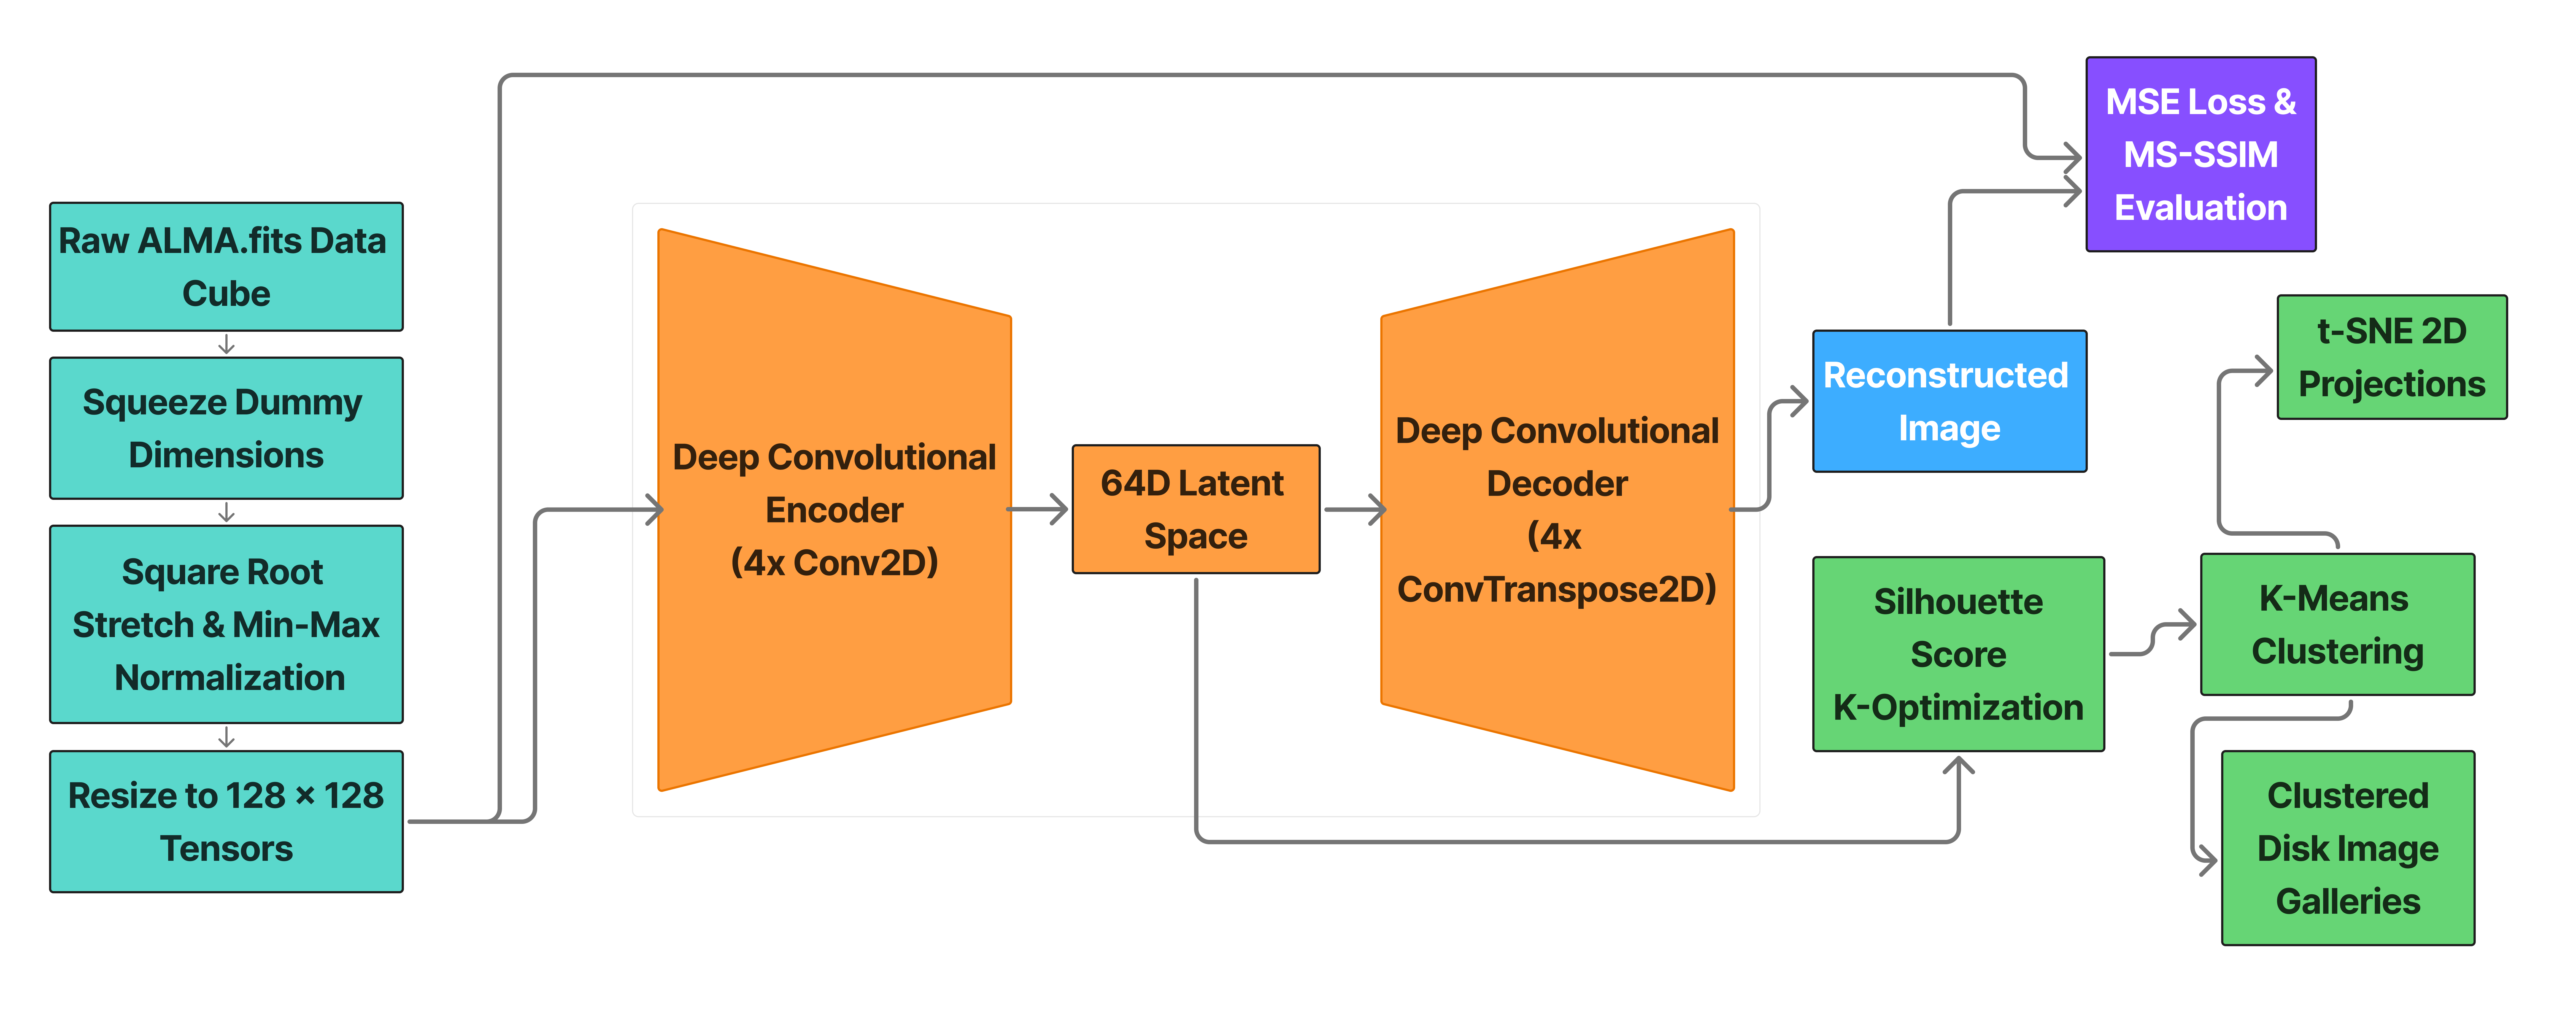

# 1. Data Loading and Preprocessing
The following section handles the robust loading of `.fits` files, extraction of the 0th index, and normalization using astronomical standards (square root stretch to boost faint features).

In [ ]:
def load_and_preprocess_fits(file_path):
    with fits.open(file_path) as hdul:
        # Robustly squeeze out dummy dimensions (e.g., polarization, frequency)
        data = np.squeeze(hdul[0].data)

        # Grab strictly the 0th layer if it's still a cube
        if data.ndim >= 3:
            img = data[0, :, :]
        else:
            img = data

        img = np.array(img, dtype=np.float32)
        img = np.nan_to_num(img, nan=0.0)

        # --- Preprocessing Pipeline ---
        # 1. Shift data so the minimum is 0 (removes negative noise)
        img = img - np.min(img)

        # 2. Apply a Square Root Stretch (boosts faint features)
        img = np.sqrt(img)

        # 3. Apply Min-Max Normalization (0 to 1 scaling)
        img_min, img_max = np.min(img), np.max(img)
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)

    return img

class ProtoplanetaryDiskDataset(Dataset):
    def __init__(self, data_directory):
        self.data_directory = data_directory
        self.file_paths = glob.glob(os.path.join(data_directory, '*.fits'))

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]

        # Load and preprocess the 2D image
        img = load_and_preprocess_fits(file_path)

        # Convert to tensor and add channel dimension -> (1, 600, 600)
        img_tensor = torch.tensor(img).unsqueeze(0)

        # Resize to 128x128 to optimize memory and speed up Autoencoder training
        resize = T.Resize((128, 128), antialias=True)
        img_tensor = resize(img_tensor)

        return img_tensor, file_path

Total FITS files loaded into dataset: 150
Batch Shape: torch.Size([8, 1, 128, 128]) (Expected: [8, 1, 128, 128])


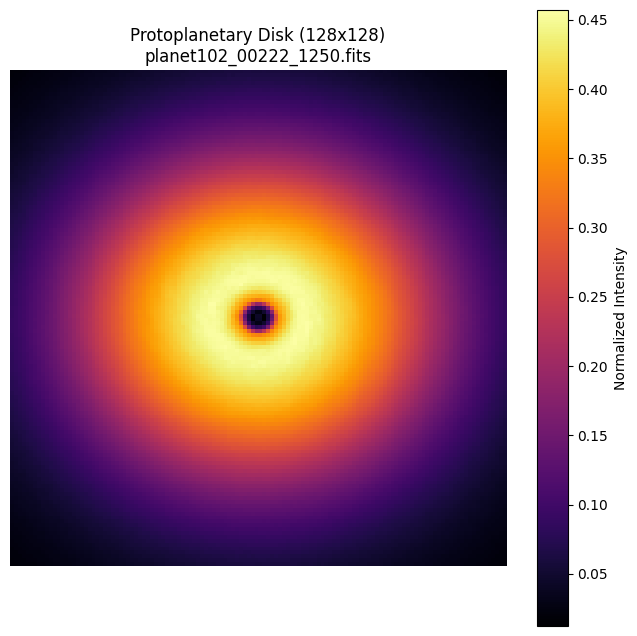

In [ ]:
# Path to the FITS dataset
DATA_DIR = '/content/continuum_data/continuum_data_subset'

# Initialize Dataset and DataLoader
disk_dataset = ProtoplanetaryDiskDataset(DATA_DIR)
print(f"Total FITS files loaded into dataset: {len(disk_dataset)}")

data_loader = DataLoader(disk_dataset, batch_size=8, shuffle=True)

# Verify shapes and plot a sample
if len(disk_dataset) > 0:
    sample_imgs, _ = next(iter(data_loader))
    print(f"Batch Shape: {sample_imgs.shape} (Expected: [8, 1, 128, 128])")

    sample_img, sample_path = disk_dataset[0]
    plot_img = sample_img.squeeze().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(plot_img, cmap='inferno', origin='lower')
    plt.colorbar(label='Normalized Intensity')
    plt.title(f"Protoplanetary Disk (128x128)\n{os.path.basename(sample_path)}")
    plt.axis('off')
    plt.show()

# 2. Image-Based Test: Autoencoder
Training a Convolutional Autoencoder to compress the images into an accessible latent space and reconstruct them.

In [ ]:
class ProtoplanetaryAutoencoder(nn.Module):
    def __init__(self, latent_dim=64): # using 64 as default based on training script
        super(ProtoplanetaryAutoencoder, self).__init__()

        # ENCODER
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 256 * 8 * 8)

        # DECODER
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        return self.fc_mu(x)

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(-1, 256, 8, 8)
        return self.decoder(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

In [ ]:
# Initialize Model, Loss, and Optimizer
latent_dimensions = 64
model = ProtoplanetaryAutoencoder(latent_dim=latent_dimensions).to(device)
weights_path = '/content/exxa_autoencoder_weights.pth'

# Check if pre-trained weights exist. If yes, load them. If no, train from scratch.
if os.path.exists(weights_path):
    print("Pre-trained model found! Loading weights to save time...")
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print("✅ Model loaded successfully!")
else:
    print("No pre-trained model found. Initiating training loop...")
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    epochs = 20

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for images, _ in progress_bar:
            images = images.to(device)
            optimizer.zero_grad()
            reconstructed = model(images)
            loss = criterion(reconstructed, images)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress_bar.set_postfix({'Loss': f"{loss.item():.4f}"})

        avg_loss = epoch_loss / len(data_loader)
        print(f"Epoch {epoch+1} Completed | Average MSE Loss: {avg_loss:.6f}")

    # Save weights after training
    torch.save(model.state_dict(), weights_path)
    print("✅ Training complete and model saved locally!")

Pre-trained model found! Loading weights to save time...
✅ Model loaded successfully!


# 3. Model Evaluation (Quantitative and Qualitative Metrics)
Visualizing reconstruction capabilities and calculating Multiscale Structural Similarity Index Measure (MS-SSIM).

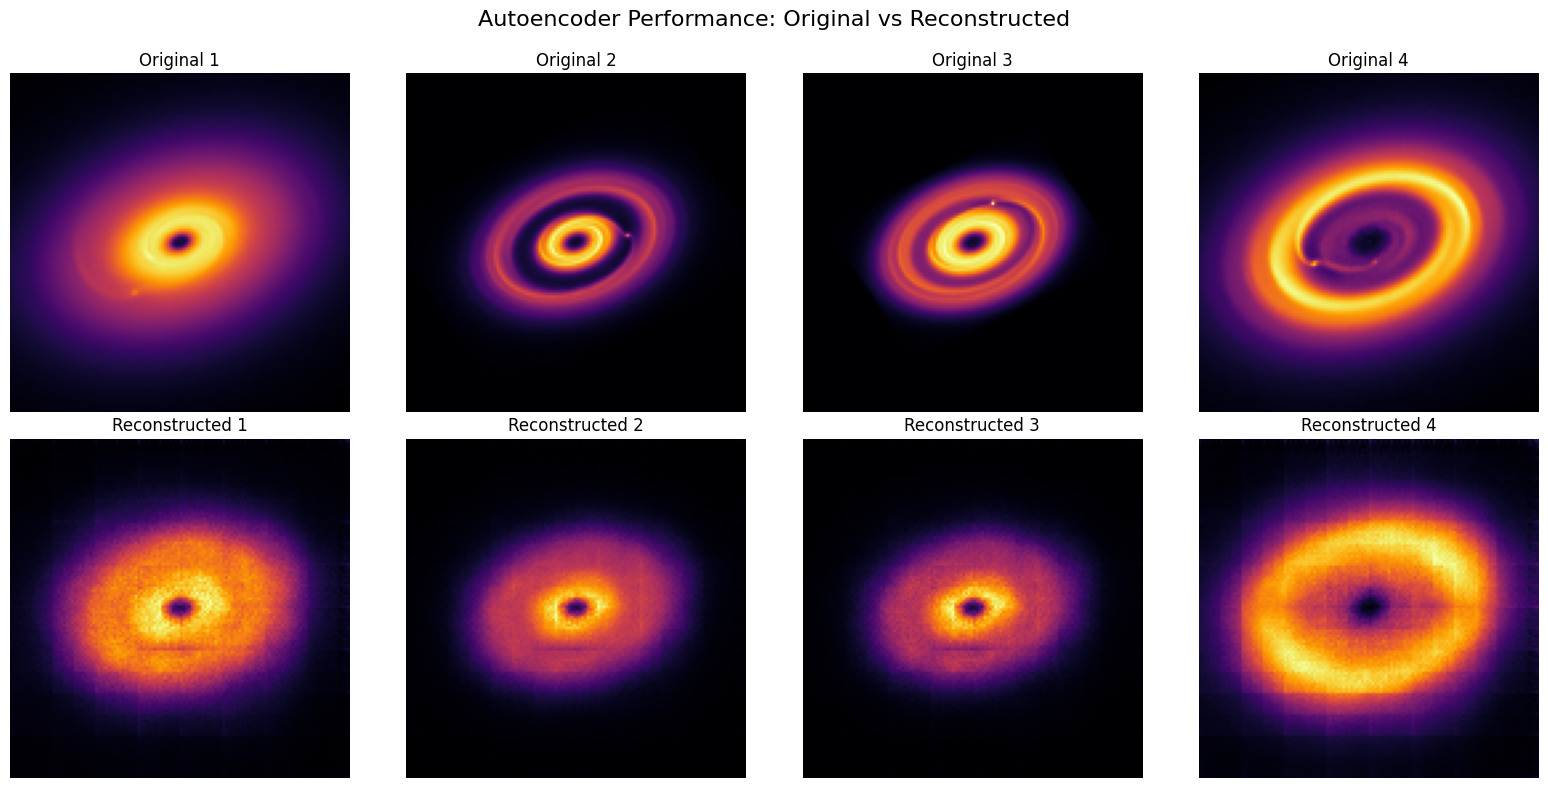

In [ ]:
model.eval()

with torch.no_grad():
    sample_images, _ = next(iter(data_loader))
    sample_images = sample_images.to(device)
    reconstructed_images = model(sample_images)

    sample_images = sample_images.cpu().squeeze().numpy()
    reconstructed_images = reconstructed_images.cpu().squeeze().numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Autoencoder Performance: Original vs Reconstructed', fontsize=16)

for i in range(4):
    axes[0, i].imshow(sample_images[i], cmap='inferno', origin='lower')
    axes[0, i].set_title(f"Original {i+1}")
    axes[0, i].axis('off')

    axes[1, i].imshow(reconstructed_images[i], cmap='inferno', origin='lower')
    axes[1, i].set_title(f"Reconstructed {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [ ]:
model.eval()
total_ms_ssim = 0.0
batches = 0

with torch.no_grad():
    for images, _ in data_loader:
        images = images.to(device)
        reconstructed = model(images)

        # Calculate MS-SSIM
        batch_msssim = ms_ssim(images, reconstructed, data_range=1.0, size_average=True, win_size=7)
        total_ms_ssim += batch_msssim.item()
        batches += 1

avg_ms_ssim = total_ms_ssim / batches
print(f"Final Average MS-SSIM Score: {avg_ms_ssim:.4f}")

Final Average MS-SSIM Score: 0.9204


In [ ]:
model.eval()

mse_criterion = nn.MSELoss()

total_mse_loss = 0.0
num_batches = 0

with torch.no_grad():
    for images, _ in data_loader:
        images = images.to(device)

        reconstructed = model(images)

        batch_loss = mse_criterion(reconstructed, images)

        total_mse_loss += batch_loss.item()
        num_batches += 1

average_mse_loss = total_mse_loss / num_batches
print(f"Final Average MSE Loss: {average_mse_loss:.6f}")

Final Average MSE Loss: 0.001120


# 4. General Test: Unsupervised Clustering
Using the autoencoder's accessible latent space, we cluster the structural representations of the disks to detect planets while ignoring superficial viewing angles.

In [ ]:
model.eval()
latent_vectors = []
image_paths_list =[]

# Extract Latent Representations
with torch.no_grad():
    for images, paths in data_loader:
        images = images.to(device)
        z = model.encode(images)

        latent_vectors.append(z.cpu().numpy())
        image_paths_list.extend(paths)

latent_vectors = np.concatenate(latent_vectors, axis=0)
print(f"Extracted Latent Space Shape: {latent_vectors.shape}")

# Find Optimal Clusters using Silhouette Score
print("\nTesting different cluster sizes...")
best_k = 2
best_score = -1

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(latent_vectors)
    score = silhouette_score(latent_vectors, labels)
    print(f"Number of clusters: {k} | Silhouette Score: {score:.4f}")
    if score > best_score:
        best_k = k
        best_score = score

print(f"\nOptimal number of clusters chosen: {best_k}")

# Fit final model
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(latent_vectors)

Extracted Latent Space Shape: (150, 64)

Testing different cluster sizes...
Number of clusters: 2 | Silhouette Score: 0.4001
Number of clusters: 3 | Silhouette Score: 0.3569
Number of clusters: 4 | Silhouette Score: 0.3350
Number of clusters: 5 | Silhouette Score: 0.3485
Number of clusters: 6 | Silhouette Score: 0.3253

Optimal number of clusters chosen: 2


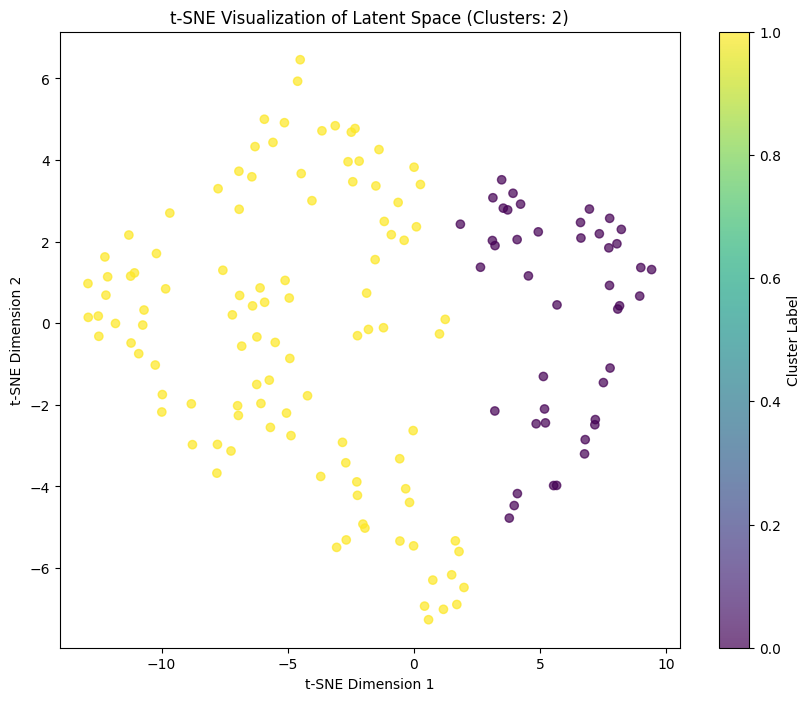

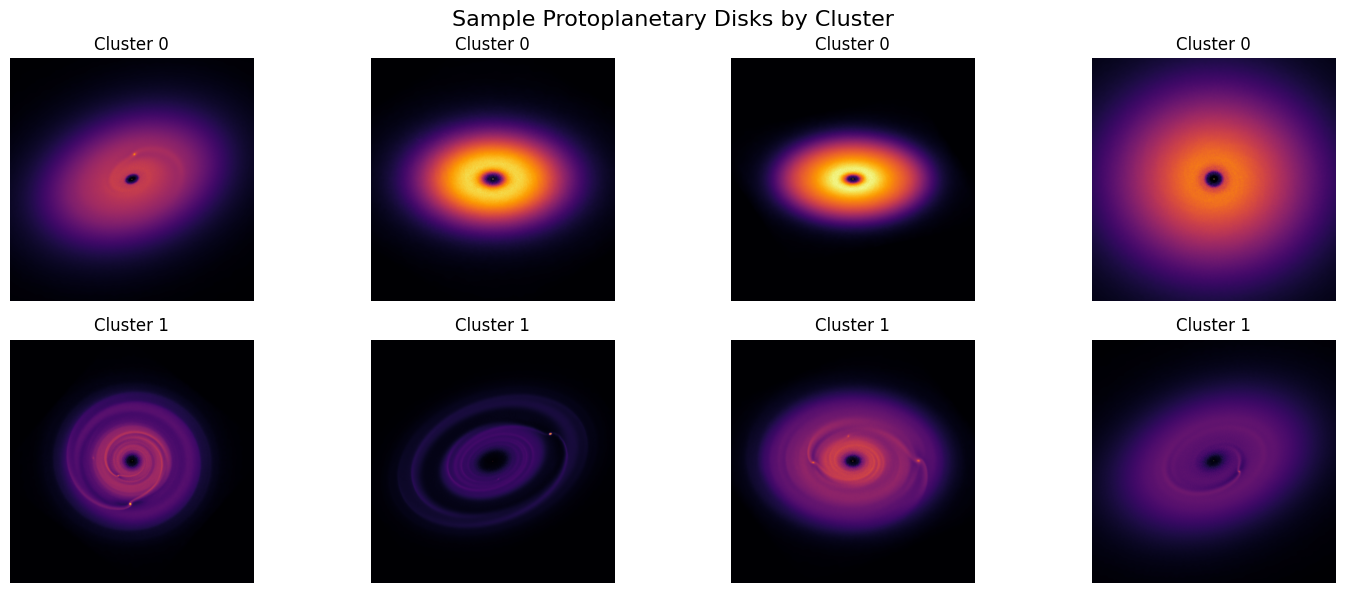

In [ ]:
# --- VISUALIZATION 1: t-SNE Scatter Plot ---
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(latent_vectors)-1))
latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster Label')
plt.title(f"t-SNE Visualization of Latent Space (Clusters: {best_k})")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

# --- VISUALIZATION 2: Cluster Image Gallery ---
fig, axes = plt.subplots(best_k, 4, figsize=(15, 3 * best_k))
fig.suptitle("Sample Protoplanetary Disks by Cluster", fontsize=16)

if best_k == 1: axes = np.expand_dims(axes, axis=0)

for cluster_idx in range(best_k):
    indices = np.where(cluster_labels == cluster_idx)[0]
    sample_indices = indices[:4]

    for i, img_idx in enumerate(sample_indices):
        img_path = image_paths_list[img_idx]
        original_img = load_and_preprocess_fits(img_path)

        ax = axes[cluster_idx, i]
        ax.imshow(original_img, cmap='inferno', origin='lower')
        ax.set_title(f"Cluster {cluster_idx}")
        ax.axis('off')

    for i in range(len(sample_indices), 4):
        axes[cluster_idx, i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### Conclusion and Cluster Analysis

The pipeline successfully groups the protoplanetary disks without labels by utilizing the latent space of the trained Autoencoder. By clustering on the compressed latent vectors rather than raw pixels, the model effectively isolates structural features.

As seen in the sample gallery:
- **Cluster 0** identifies more continuous, diffuse disks without prominent gaps.
- **Cluster 1** identifies disks with clear, prominent planetary signatures (deep gaps and distinct rings indicating clearing by orbiting planets).

Most importantly, the model successfully avoids clustering based on viewing angle. Disks of varying inclinations (both face-on and highly tilted) are correctly grouped together based on their internal structure (presence or absence of planetary gaps) rather than their orientation.